In [3]:
from __future__ import print_function, division

import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Reshape, Flatten
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras import Sequential, Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from skimage.transform import resize
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, average_precision_score
import scipy.io
import itertools
import time
import shutil
import os

In [4]:
from GAN import GAN
cell_dir='dataset_A/cell_level_label'

In [5]:
X_train = np.load(f'{cell_dir}/X_train.npy')
X_test = np.load(f'{cell_dir}/X_test.npy')
y_train = np.load(f'{cell_dir}/y_train.npy')
y_test = np.load(f'{cell_dir}/y_test.npy')

X_train_resized = np.empty([X_train.shape[0], 32, 32, 3])
for i in range(X_train.shape[0]):
    X_train_resized[i] = resize(X_train[i], (32, 32, 3), mode='reflect')

X_test_resized = np.empty([X_test.shape[0], 32, 32, 3])
for i in range(X_test.shape[0]):
    X_test_resized[i] = resize(X_test[i], (32, 32, 3), mode='reflect')

X_train_resized = 2 * X_train_resized - 1
X_test_resized = 2 * X_test_resized - 1


(1631, 32, 32, 3)


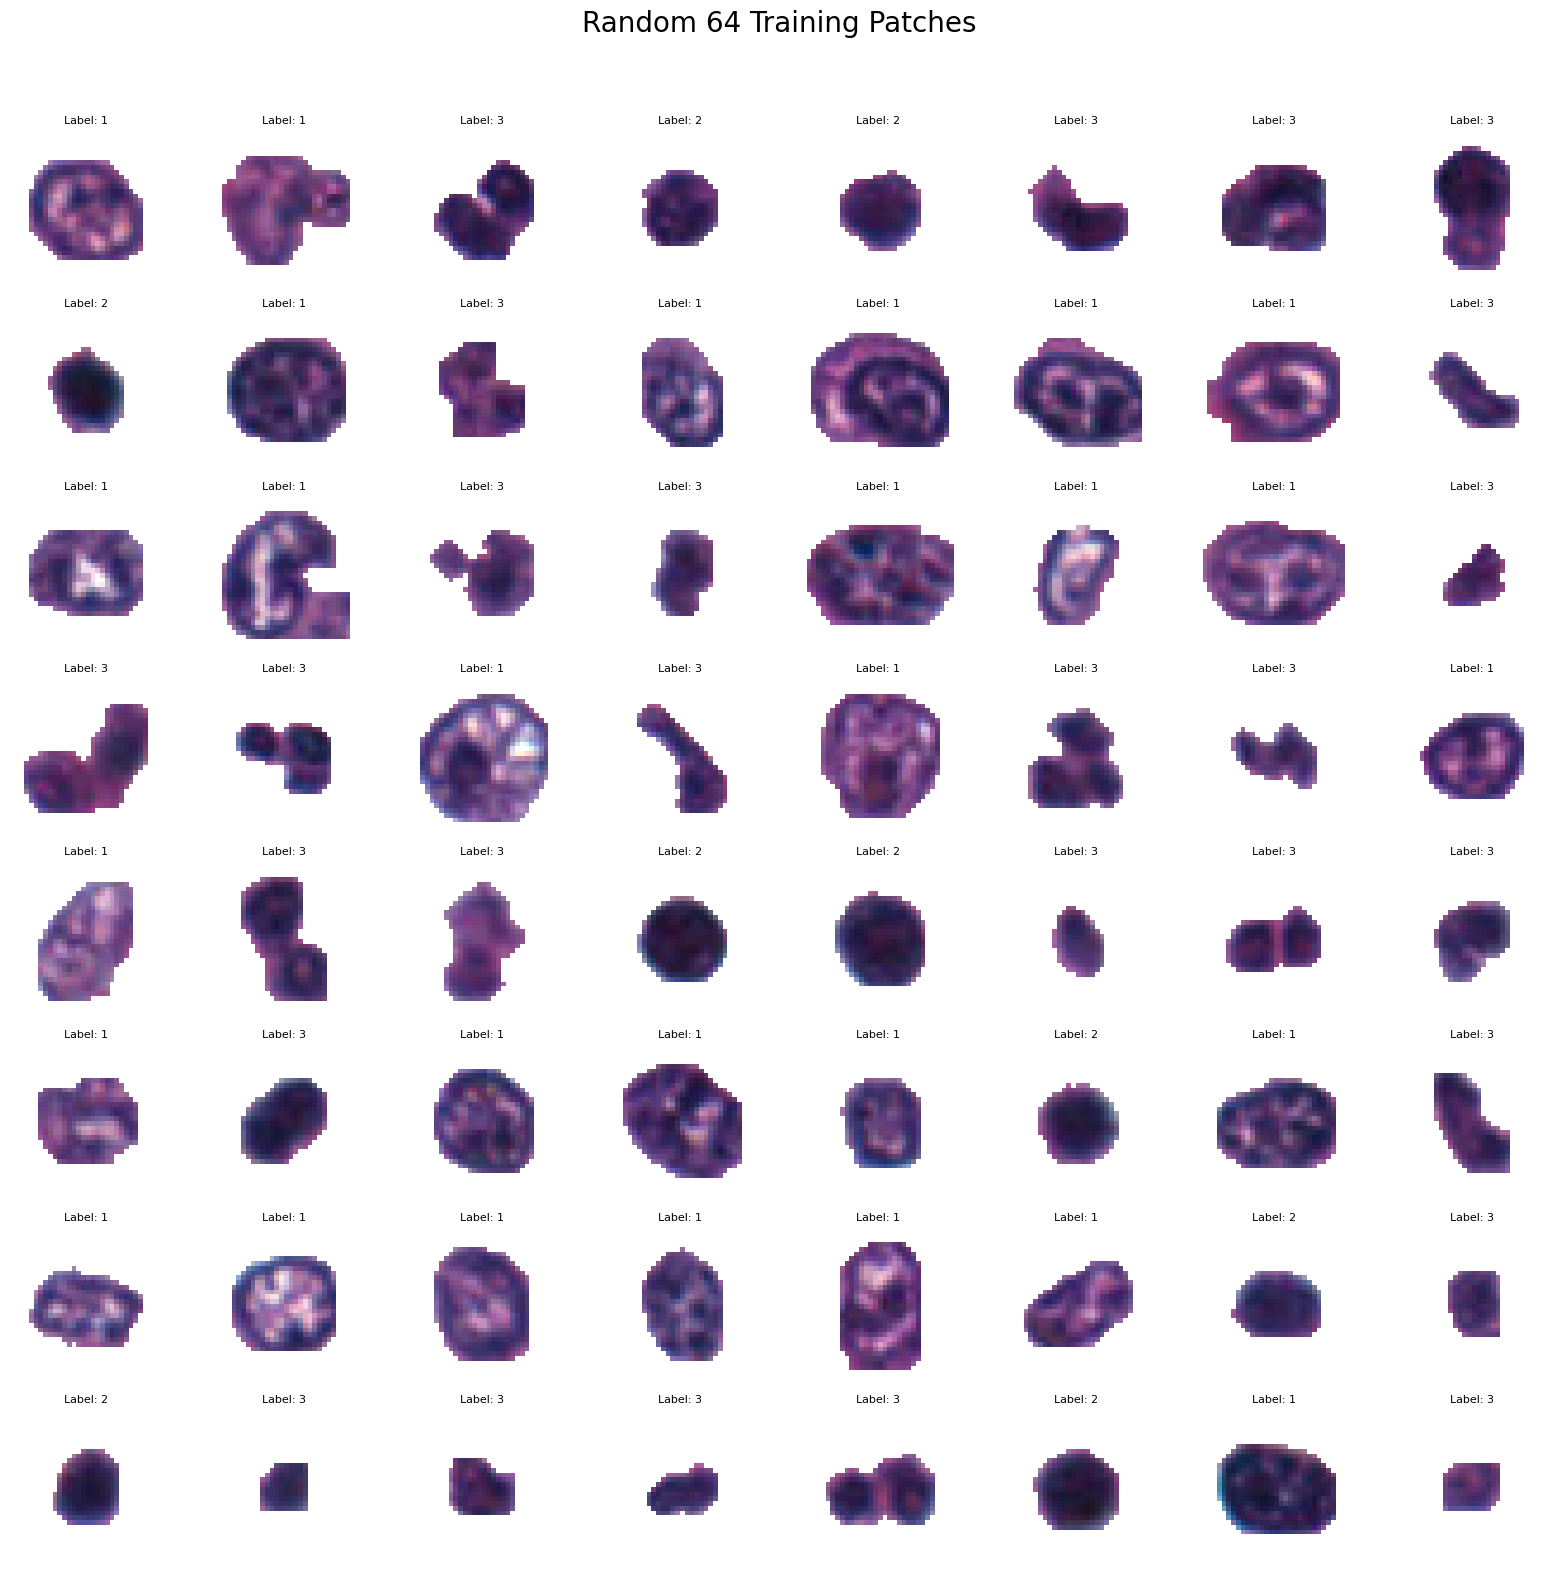

In [6]:
X_train_dis = (X_train_resized + 1) / 2.0
print(X_train_dis.shape)

n_plot = min(64, X_train_dis.shape[0]) 
random_indices = np.random.choice(X_train_dis.shape[0], n_plot, replace=False)
plt.figure(figsize=(16, 16)) 
for idx, random_idx in enumerate(random_indices):
    ax = plt.subplot(8, 8, idx + 1)
    ax.imshow(X_train_dis[random_idx])
    lbl = y_train[random_idx][0] if y_train.ndim > 1 else y_train[random_idx]
    ax.set_title(f"Label: {lbl}", fontsize=8)
    ax.axis('off')

plt.suptitle("Random 64 Training Patches", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [7]:
class LSGAN():
    def __init__(self):
        
        """
        -----------------------------------------------------------------------------------------------
        Define image shape for TMI data(32x32x3)
        -----------------------------------------------------------------------------------------------
        """ 
        self.img_rows = 32
        self.img_cols = 32
        self.channels = 3
        self.img_shape = (self.img_rows, self.img_cols, self.channels)
        
        """
        -----------------------------------------------------------------------------------------------
        Define class and latent
        -----------------------------------------------------------------------------------------------
        """    
        self.num_classes = 4 # modify this if needed
        self.latent_dim = 100
        
        """
        -----------------------------------------------------------------------------------------------
         Define training history
        -----------------------------------------------------------------------------------------------
        """         
        self.training_history = {
                'D_loss': [],
                'D_acc': [],
                'G_loss': [],
                'G_acc': [],
                }

        """
        -----------------------------------------------------------------------------------------------
         Build discriminator model
        -----------------------------------------------------------------------------------------------
        """
        self.discriminator = self.build_discriminator()
        
        """
        -----------------------------------------------------------------------------------------------
         Compile discriminator using Adam optimizer
         binary crossentropy is used to distinguish among real or fake samples
         categorical entropy is to distinguish among which real category is (nuclei or non-nuclei)
        -----------------------------------------------------------------------------------------------
        """ 
        optimizer =  Adam(learning_rate=0.0002, beta_1=0.5)
        self.discriminator.compile(loss=['mse', 'categorical_crossentropy'],
            optimizer=optimizer,
            metrics=['accuracy'])

        """
        -----------------------------------------------------------------------------------------------
         Build the generator
        -----------------------------------------------------------------------------------------------
        """ 
        self.generator = self.build_generator()

        """
        -----------------------------------------------------------------------------------------------
         The generator takes noise as input and generates imgs
        -----------------------------------------------------------------------------------------------
        """  
        z = Input(shape=(self.latent_dim,))
        img = self.generator(z)

        """
        -----------------------------------------------------------------------------------------------
         For the combined model only generator is trained
        -----------------------------------------------------------------------------------------------
        """ 
        self.discriminator.trainable = False

        """
        -----------------------------------------------------------------------------------------------
         The discriminator takes generated images as input and determines validity
        -----------------------------------------------------------------------------------------------
        """ 
        validity, _ = self.discriminator(img)

        """
        -----------------------------------------------------------------------------------------------
         The combined model (generator and discriminator) takes 
         noise as input => generates images => determines validity
        -----------------------------------------------------------------------------------------------
        """       
        self.combined = Model(z, validity)
        self.combined.compile(loss='mse', optimizer=optimizer)


    def build_generator(self):
        
        """
        -----------------------------------------------------------------------------------------------
         Model creation for generator
        -----------------------------------------------------------------------------------------------
        """ 
        model = Sequential()

        """
        -----------------------------------------------------------------------------------------------
         Add layers
        -----------------------------------------------------------------------------------------------
        """  
        model.add(Dense(128 * 8 * 8, activation="relu", input_dim=self.latent_dim)) 
        model.add(BatchNormalization(momentum=0.8))
        model.add(Dense(256))
        model.add(LeakyReLU(alpha=0.2))
        model.add(BatchNormalization(momentum=0.8))
        model.add(Dense(512))
        model.add(LeakyReLU(alpha=0.2))
        model.add(BatchNormalization(momentum=0.8))
        model.add(Dense(1024))
        model.add(LeakyReLU(alpha=0.2))
        model.add(BatchNormalization(momentum=0.8))
        model.add(Dense(np.prod(self.img_shape), activation='tanh'))
        model.add(Reshape(self.img_shape))

        """
        -----------------------------------------------------------------------------------------------
         Generate noise and Image
        -----------------------------------------------------------------------------------------------
        """           
        noise = Input(shape=(self.latent_dim,))
        img = model(noise)
        
        """
        -----------------------------------------------------------------------------------------------
         Return Model
        -----------------------------------------------------------------------------------------------
        """ 
        return Model(noise, img)
    

    def build_discriminator(self):
        """
        -----------------------------------------------------------------------------------------------
         Model creation for discriminator
        -----------------------------------------------------------------------------------------------
        """ 
        model = Sequential()
        
        """
        -----------------------------------------------------------------------------------------------
        Add layers
        -----------------------------------------------------------------------------------------------
        """ 
        model.add(Flatten(input_shape=self.img_shape))
        model.add(Dense(512))
        model.add(LeakyReLU(alpha=0.2))
        model.add(Dense(256))
        model.add(LeakyReLU(alpha=0.2))
        model.add(Dense(1))
        
        """
        -----------------------------------------------------------------------------------------------
         Gereate image and features
        -----------------------------------------------------------------------------------------------
        """ 
        img = Input(shape=self.img_shape)
        features = model(img)
        
        """
        -----------------------------------------------------------------------------------------------
         valid indicates if the image is real or fake
        -----------------------------------------------------------------------------------------------
        """ 
        valid = Dense(1, activation="sigmoid")(features)
        
        """
        -----------------------------------------------------------------------------------------------
         label indicates which type of image it is
        -----------------------------------------------------------------------------------------------
        """ 
        label = Dense(self.num_classes+1, activation="softmax")(features)
        
        """
        -----------------------------------------------------------------------------------------------
         Return model
        -----------------------------------------------------------------------------------------------
        """ 
        return Model(img, [valid, label])
    

    def train(self, X_train, y_train, X_test, y_test, epochs, batch_size, save_interval):
        
        """
        -----------------------------------------------------------------------------------------------
         Delete directory if exist and create it
        -----------------------------------------------------------------------------------------------
        """ 
        shutil.rmtree('LSGAN_generated_output', ignore_errors=True)
        os.makedirs("LSGAN_generated_output")

        """
        -----------------------------------------------------------------------------------------------
         Adversarial ground truths
        -----------------------------------------------------------------------------------------------
        """
        valid = np.ones((batch_size, 1))
        fake = np.zeros((batch_size, 1))

        for epoch in range(epochs):

            """
            -----------------------------------------------------------------------------------------------
             Training the Discriminator
             Select a random batch of images
            -----------------------------------------------------------------------------------------------
            """ 
            idx = np.random.randint(0, X_train.shape[0], batch_size)
            imgs = X_train[idx]

            noise = np.random.normal(0, 1, (batch_size, self.latent_dim))
            """
            -----------------------------------------------------------------------------------------------
             Generate a batch of new images
            -----------------------------------------------------------------------------------------------
            """              
            gen_imgs = self.generator.predict(noise)

            """
            -----------------------------------------------------------------------------------------------
             Convert labels to categorical one-hot encoding
            -----------------------------------------------------------------------------------------------
            """ 
            
            # print(self.num_classes)
            labels = tf.keras.utils.to_categorical(y_train[idx], num_classes=self.num_classes+1)
            fake_labels = tf.keras.utils.to_categorical(np.full((batch_size, 1), 
                                                        self.num_classes),
                                                        num_classes=self.num_classes+1)

            """
            -----------------------------------------------------------------------------------------------
             Train the discriminator
            -----------------------------------------------------------------------------------------------
            """  
            d_loss_real = self.discriminator.train_on_batch(imgs, [valid, labels])
            d_loss_fake = self.discriminator.train_on_batch(gen_imgs, [fake, fake_labels])
            d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

            """
            -----------------------------------------------------------------------------------------------
             Train Generator
            -----------------------------------------------------------------------------------------------
            """
            noise = np.random.normal(0, 1, (batch_size, self.latent_dim))
            
            """
            -----------------------------------------------------------------------------------------------
             Train the generator (to have the discriminator label samples as valid)
            -----------------------------------------------------------------------------------------------
            """
            g_loss = self.combined.train_on_batch(noise, valid)
            
            """
            -----------------------------------------------------------------------------------------------
             Add history data
            -----------------------------------------------------------------------------------------------
            """ 
            self.training_history["D_loss"].append(d_loss[0]);
            self.training_history["D_acc"].append(100*d_loss[3]);
            self.training_history["G_loss"].append(g_loss);
            self.training_history["G_acc"].append(100*d_loss[4]);
            
            """
            -----------------------------------------------------------------------------------------------
             Print the result
            -----------------------------------------------------------------------------------------------
            """ 
            print ("%d: Training D [loss: %.4f, acc: %.2f%% ] - G [loss: %.4f, acc: %.2f%%]" 
                   % (epoch, d_loss[0], 100*d_loss[3], g_loss, 100*d_loss[4]))
            
            """
            -----------------------------------------------------------------------------------------------
             Evaluate test data for each epoch
            -----------------------------------------------------------------------------------------------
            """   
            self.evaluate_discriminator(X_test, y_test)

            """
            -----------------------------------------------------------------------------------------------
             If at save interval => save generated image samples
            -----------------------------------------------------------------------------------------------
            """ 
            if epoch % save_interval == 0:
                self.save_images(epoch)


    def evaluate_discriminator(self, X_test, y_test):
        valid = np.ones((y_test.shape[0], 1))
        
        """
        -----------------------------------------------------------------------------------------------
         Convert labels to categorical one-hot encoding
        -----------------------------------------------------------------------------------------------
        """ 
        labels = tf.keras.utils.to_categorical(y_test, num_classes=self.num_classes+1)
        
        """
        -----------------------------------------------------------------------------------------------
         Evaluating the trained Discriminator and print outputs
        -----------------------------------------------------------------------------------------------
        """ 
        scores = self.discriminator.evaluate(X_test, [valid, labels], verbose=0)

        print("Evaluating D [loss:  %.4f, bi-loss: %.4f, cat-loss: %.4f, bi-acc: %.2f%%, cat-acc: %.2f%%]\n" %
              (scores[0], scores[1], scores[2], scores[3]*100, scores[4]*100))

        return (scores[0], scores[3]*100)    
    
        
    def save_images(self, epoch):
        r, c = 5, 5
        noise = np.random.normal(0, 1, (r * c, self.latent_dim))
        gen_imgs = self.generator.predict(noise)

        """
        -----------------------------------------------------------------------------------------------
         Rescale images from [-1..1] to [0..1] just to display purposes.
        -----------------------------------------------------------------------------------------------
        """
        gen_imgs = 0.5 * gen_imgs + 0.5

        fig, axs = plt.subplots(r, c)
        cnt = 0
        for i in range(r):
            for j in range(c):
                axs[i,j].imshow(gen_imgs[cnt, :,:])
                axs[i,j].axis('off')
                cnt += 1
        
        """
        -----------------------------------------------------------------------------------------------
          Save generator image for each epoch
        -----------------------------------------------------------------------------------------------
        """ 
        fig.savefig("./LSGAN_generated_output/lsgan_%d.png" % epoch)
        plt.close()
        
        
    def save_model(self):

        def save(model, model_name):
            
            """
            -----------------------------------------------------------------------------------------------
            Save weights
            -----------------------------------------------------------------------------------------------
            """
            model_path = "./LSGAN_saved_models/%s.json" % model_name
            weights_path = "./LSGAN_saved_models/%s_weights.hdf5" % model_name
            options = {"file_arch": model_path,
                        "file_weight": weights_path}
            json_string = model.to_json()
            open(options['file_arch'], 'w').write(json_string)
            model.save_weights(options['file_weight'])

        shutil.rmtree('LSGAN_saved_models', ignore_errors=True)
        os.makedirs("LSGAN_saved_models")
        
        """
        -----------------------------------------------------------------------------------------------
          Save models
        -----------------------------------------------------------------------------------------------
        """ 
        save(self.generator, "LSGAN_gan_generator")
        save(self.discriminator, "LSGAN_gan_discriminator")
        save(self.combined, "LSGAN_gan_adversarial")
        

    def plot_training_history(self):
        """
        -----------------------------------------------------------------------------------------------
          Plot training history
        -----------------------------------------------------------------------------------------------
        """ 
        fig, axs = plt.subplots(1,2,figsize=(15,5))
        plt.title('Training History')

        """
        -----------------------------------------------------------------------------------------------
          Summarize history for G and D accuracy
        -----------------------------------------------------------------------------------------------
        """
        axs[0].plot(range(1,len(self.training_history['D_acc'])+1),self.training_history['D_acc'])
        axs[0].plot(range(1,len(self.training_history['G_acc'])+1),self.training_history['G_acc'])
        axs[0].set_title('D and G Accuracy')
        axs[0].set_ylabel('Accuracy')
        axs[0].set_xlabel('Epoch')
        axs[0].set_xticks(np.arange(1,len(self.training_history['D_acc'])+1),len(self.training_history['D_acc'])/10)
        axs[0].set_yticks([n for n in range(0, 101,10)])
        axs[0].legend(['Discriminator', 'Generator'], loc='best')

        """
        -----------------------------------------------------------------------------------------------
          Summarize history for G and D loss
        -----------------------------------------------------------------------------------------------
        """
        axs[1].plot(range(1,len(self.training_history['D_loss'])+1),self.training_history['D_loss'])
        axs[1].plot(range(1,len(self.training_history['G_loss'])+1),self.training_history['G_loss'])
        axs[1].set_title('D and G Loss')
        axs[1].set_ylabel('Loss')
        axs[1].set_xlabel('Epoch')
        axs[1].set_xticks(np.arange(1,len(self.training_history['G_loss'])+1),len(self.training_history['G_loss'])/10)
        axs[1].legend(['Discriminator', 'Generator'], loc='best')
                
        """
        -----------------------------------------------------------------------------------------------
         Plot training history
        -----------------------------------------------------------------------------------------------
        """
        plt.show()


    def predict(self, X_test, y_test):
        
        """
        -----------------------------------------------------------------------------------------------
        Generating a predictions from the discriminator over the testing dataset
        -----------------------------------------------------------------------------------------------
        """ 
        y_pred = self.discriminator.predict(X_test)
        
        """
        -----------------------------------------------------------------------------------------------
         Formating predictions to remove the one_hot_encoding format
        -----------------------------------------------------------------------------------------------
        """ 
        y_pred = np.argmax(y_pred[1][:,:-1], axis=1)
        
        """
        -----------------------------------------------------------------------------------------------
         Calculating and ploting a Classification Report
        -----------------------------------------------------------------------------------------------
        """ 
        print ('\nOverall accuracy: %f%% \n' % (accuracy_score(y_test, y_pred) * 100))
        print ('\nAveP: %f%% \n' % (average_precision_score(y_test, y_pred) * 100))        
        class_names = ['Non-nuclei', 'Nuclei']
        print("Classification report:\n %s\n"
              % (classification_report(y_test, y_pred, target_names=class_names)))
        
        """
        -----------------------------------------------------------------------------------------------
         Output Confusion matrix
        -----------------------------------------------------------------------------------------------
        """ 
        cm = confusion_matrix(y_test, y_pred)

        plt.figure()
        plot_confusion_matrix(cm, class_names, title='Confusion matrix')
            

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    -----------------------------------------------------------------------------------------------
     Prints and plots the confusion matrix
    -----------------------------------------------------------------------------------------------
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
        
        
def load_cell_dataset_npy(cell_dir):
    """
    -----------------------------------------------------------------------------------------------
     Load pre-cropped cell images from .npy files
    -----------------------------------------------------------------------------------------------
    """
    X_train = np.load(f'{cell_dir}/X_train.npy')
    X_test = np.load(f'{cell_dir}/X_test.npy')
    y_train = np.load(f'{cell_dir}/y_train.npy')
    y_test = np.load(f'{cell_dir}/y_test.npy')

    """
    -----------------------------------------------------------------------------------------------
     Resize images to 32x32 if needed
    -----------------------------------------------------------------------------------------------
    """
    X_train_resized = np.empty([X_train.shape[0], 32, 32, 3])
    for i in range(X_train.shape[0]):
        X_train_resized[i] = resize(X_train[i], (32, 32, 3), mode='reflect')

    X_test_resized = np.empty([X_test.shape[0], 32, 32, 3])
    for i in range(X_test.shape[0]):
        X_test_resized[i] = resize(X_test[i], (32, 32, 3), mode='reflect')

    """
    -----------------------------------------------------------------------------------------------
     Normalize images from [0..1] to [-1..1]
    -----------------------------------------------------------------------------------------------
    """
    X_train_resized = 2 * X_train_resized - 1
    X_test_resized = 2 * X_test_resized - 1

    return X_train_resized, y_train, X_test_resized, y_test


In [8]:
X_train, y_train, X_test, y_test = load_cell_dataset_npy('dataset_A/cell_level_label')
print("Unique labels in y_train:", np.unique(y_train))
print("Unique labels in y_test:", np.unique(y_test))
gan=LSGAN()

Unique labels in y_train: [0 1 2 3]
Unique labels in y_test: [0 1 2 3]


In [9]:
start = time.time() 
gan.train(X_train, y_train, X_test, y_test, epochs=2000, batch_size=32, save_interval=10)
end = time.time()
print ("\nTraining time: %0.1f minutes \n" % ((end-start) / 60))
gan.save_model()

1/1 [==============================] - 1s 1s/step
0: Training D [loss: 2.3978, acc: 43.75% ] - G [loss: 0.3351, acc: 9.38%]
Evaluating D [loss:  6.3715, bi-loss: 0.0000, cat-loss: 6.3715, bi-acc: 100.00%, cat-acc: 25.27%]

1/1 [==============================] - 0s 128ms/step
1: Training D [loss: 3.9873, acc: 62.50% ] - G [loss: 0.3144, acc: 15.62%]
Evaluating D [loss:  1.7828, bi-loss: 0.2079, cat-loss: 1.5749, bi-acc: 70.60%, cat-acc: 34.89%]

1/1 [==============================] - 0s 218ms/step
2: Training D [loss: 1.8044, acc: 56.25% ] - G [loss: 0.2851, acc: 17.19%]
Evaluating D [loss:  2.3630, bi-loss: 0.8002, cat-loss: 1.5628, bi-acc: 0.00%, cat-acc: 36.26%]

1/1 [==============================] - 0s 141ms/step
3: Training D [loss: 2.1598, acc: 50.00% ] - G [loss: 0.2192, acc: 17.19%]
Evaluating D [loss:  2.9816, bi-loss: 0.0083, cat-loss: 2.9733, bi-acc: 99.73%, cat-acc: 25.55%]

1/1 [==============================] - 0s 210ms/step
4: Training D [loss: 2.1870, acc: 100.00% ] - G

TypeError: 200.0 must be a sequence

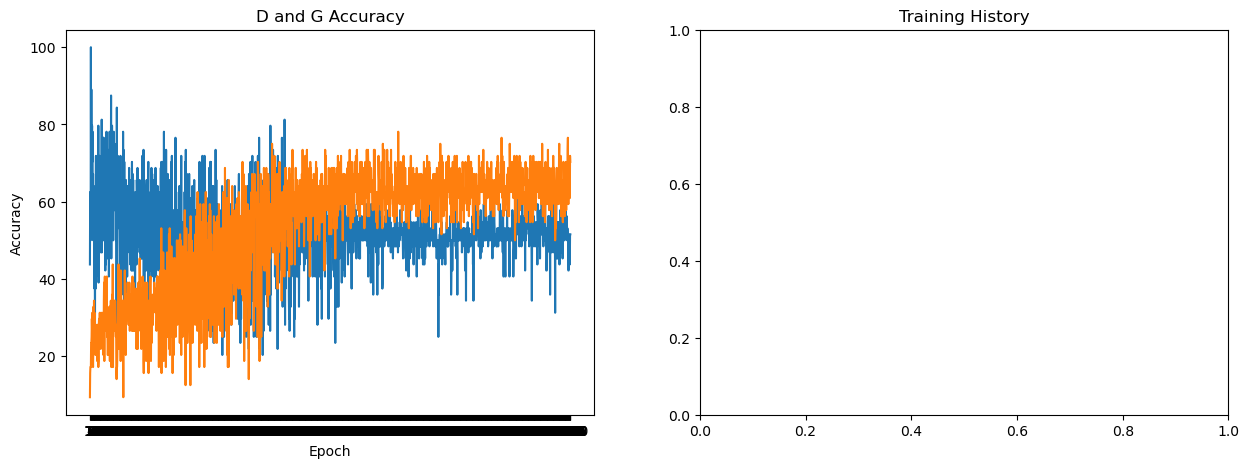

In [11]:
gan.plot_training_history()

In [12]:
gan.evaluate_discriminator(X_test,y_test)

Evaluating D [loss:  2.3974, bi-loss: 0.7061, cat-loss: 1.6913, bi-acc: 0.00%, cat-acc: 30.77%]



(2.397388219833374, 0.0)

In [13]:
gan.predict(X_test,y_test)

12/12 [==============================] - 0s 4ms/step

Overall accuracy: 59.340659% 



ValueError: Expected 2D array, got 1D array instead:
array=[3 3 3 3 3 3 3 1 1 1 1 3 1 1 1 1 1 1 1 1 1 1 1 3 1 1 1 3 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 3 1 1 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 3 1 3 1 1 1 1 3 3 1 1 3 3 1 3 1 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 1 3 3 3 3 3 3 3 3 3 3 3 3 1 3 3 3
 3 3 3 1 3 3 3 1 3 3 3 3 3 3 3 3 1 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 1 3 3 3 3 3 3 1 3 3 1 1 1 1 3 1 1 3 3 3 3 3 3 3 1 1 3 3 3 3 1 3 1
 3 1 3 3 3 3 3 3 3 3 3 3 3 3 1 3 1 3 3 3 3 3 1 3 1 1 3 3 1 3 3 3 1 3 3 3 3
 1 3 3 3 3 3 3 3 1 3 1 3 3 1 3 3 3 3 1 1 3 3 3 1 1 3 3 3 3 3 3 3 3 3 1 3 1
 1 3 3 3 1 3 1 3 1 3 3 3 3 1 1 3 1 3 3 3 3 3 3 3 3 3 1 3 3 3 1].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.